In [ ]:
pip install pyspark

## Q1. Spark Initialization and Data Loading

In [ ]:
import pyspark

In [ ]:
from pyspark.sql import SparkSession

In [ ]:
spark = SparkSession.builder.appName("Fraud Detection").getOrCreate()

In [ ]:
file_paths = [
    "transactions_POS.csv",
    "transactions_Desktop.csv",
    "transactions_Mobile.csv",
    "transactions_ATM.csv"
]

In [ ]:
df = spark.read.csv(file_paths, header=True, inferSchema=True)

In [ ]:
df.show(5)

+--------------------+---------------+------+---+------------+---------+----------------+------------+--------------------+----------------+-------------------+------------------+--------------------+----------------+-----------------+---------------+--------------------+--------------------+-----------+--------+--------------------+----------------+-----------------------+--------------------+
|         Customer_ID|  Customer_Name|Gender|Age|       State|     City|     Bank_Branch|Account_Type|      Transaction_ID|Transaction_Date|   Transaction_Time|Transaction_Amount|         Merchant_ID|Transaction_Type|Merchant_Category|Account_Balance|  Transaction_Device|Transaction_Location|Device_Type|Is_Fraud|Transaction_Currency|Customer_Contact|Transaction_Description|      Customer_Email|
+--------------------+---------------+------+---+------------+---------+----------------+------------+--------------------+----------------+-------------------+------------------+--------------------+----

In [ ]:
df.printSchema()

root
 |-- Customer_ID: string (nullable = true)
 |-- Customer_Name: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- State: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Bank_Branch: string (nullable = true)
 |-- Account_Type: string (nullable = true)
 |-- Transaction_ID: string (nullable = true)
 |-- Transaction_Date: string (nullable = true)
 |-- Transaction_Time: timestamp (nullable = true)
 |-- Transaction_Amount: double (nullable = true)
 |-- Merchant_ID: string (nullable = true)
 |-- Transaction_Type: string (nullable = true)
 |-- Merchant_Category: string (nullable = true)
 |-- Account_Balance: double (nullable = true)
 |-- Transaction_Device: string (nullable = true)
 |-- Transaction_Location: string (nullable = true)
 |-- Device_Type: string (nullable = true)
 |-- Is_Fraud: integer (nullable = true)
 |-- Transaction_Currency: string (nullable = true)
 |-- Customer_Contact: string (nullable = true)
 |-- 

In [ ]:
shape = (df.count(), len(df.columns))
print(shape)

(200000, 24)


In [ ]:
df.columns

['Customer_ID',
 'Customer_Name',
 'Gender',
 'Age',
 'State',
 'City',
 'Bank_Branch',
 'Account_Type',
 'Transaction_ID',
 'Transaction_Date',
 'Transaction_Time',
 'Transaction_Amount',
 'Merchant_ID',
 'Transaction_Type',
 'Merchant_Category',
 'Account_Balance',
 'Transaction_Device',
 'Transaction_Location',
 'Device_Type',
 'Is_Fraud',
 'Transaction_Currency',
 'Customer_Contact',
 'Transaction_Description',
 'Customer_Email']

## Q2. RDD Implementation



In [ ]:
# RDD from the existing DataFrame
transaction_rdd = df.rdd

In [ ]:
# Filter transformation: Isolate only fraudulent transactions
fraud_rdd = transaction_rdd.filter(lambda row: row['Is_Fraud'] == 1)

In [ ]:
fraud_rdd.count()

10088

In [ ]:
# 3. Map transformation: Extract Customer_ID and Transaction_Amount for analysis
# Creating a simple tuple of (Customer_ID, Amount)
customer_amount_rdd = fraud_rdd.map(lambda row: (row['Customer_ID'], row['Transaction_Amount']))

In [ ]:
customer_amount_rdd.count()

10088

In [ ]:
# Count action: Get the total number of fraudulent transactions
fraud_count = fraud_rdd.count()
print(f"Total Fraudulent Transactions: {fraud_count}")

Total Fraudulent Transactions: 10088


In [ ]:
# Take action: Retrieve and display the first 5 records
print("\nSample Fraudulent Transactions (Customer_ID, Amount):")
sample_frauds = customer_amount_rdd.take(5)

for record in sample_frauds:
    print(record)


Sample Fraudulent Transactions (Customer_ID, Amount):
('99d95f63-a2fa-4707-b577-f4a008e6700e', 85269.3)
('c85d7cf8-49cd-4f30-b03d-784d149b8b9b', 39955.85)
('fab811dc-9895-461d-90b0-70de21e85e07', 76437.89)
('98aa589a-f68a-4e01-bc3e-4a44f0c09838', 50499.73)
('6d3c855a-249e-4989-91ee-284bfe9bc408', 29722.53)


In [72]:
df.select("Device_Type").distinct().show(5, truncate=False)

+-----------+
|Device_Type|
+-----------+
|Mobile     |
|Desktop    |
|ATM        |
|POS        |
+-----------+



## Q3. Key-Value Operations and Persistence

In [ ]:
from pyspark import StorageLevel

In [ ]:
# 1. RDD Persistence
# Cache the RDD in memory and disk to speed up subsequent operations
customer_amount_rdd.persist(StorageLevel.MEMORY_AND_DISK)

PythonRDD[140] at RDD at PythonRDD.scala:56

In [ ]:
# 2. Key-Value & Shuffle Operations (reduceByKey)
# Calculate the total fraudulent amount per Customer_ID
total_fraud_per_customer = customer_amount_rdd.reduceByKey(lambda amount1, amount2: amount1 + amount2)

In [ ]:
# 3. Shuffle Operation (sortBy)
# Sort the results in descending order to find the highest fraud amounts
sorted_fraud = total_fraud_per_customer.sortBy(lambda x: x[1], ascending=False)

In [ ]:
# 4. Action: Display the Top 5 customers with the highest fraud amounts
print("--- Top 5 Customers by Total Fraud Amount ---")
for record in sorted_fraud.take(5):
    print(f"Customer_ID: {record[0]} | Total Fraud Amount: {record[1]:.2f}")

--- Top 5 Customers by Total Fraud Amount ---
Customer_ID: 56b3c3af-2f8b-4717-9d01-ea25c68947a7 | Total Fraud Amount: 98999.02
Customer_ID: 5cd40ed1-d60e-434d-8705-6a3177ef9385 | Total Fraud Amount: 98995.37
Customer_ID: ad017899-7b0a-4a86-9cd5-001cf119847a | Total Fraud Amount: 98994.03
Customer_ID: c6a249c6-6980-4255-8ba1-bb94770adccc | Total Fraud Amount: 98986.55
Customer_ID: 6227067a-cf80-427b-8017-de17d94aae96 | Total Fraud Amount: 98979.72


In [ ]:
# 5. Best Practice: Unpersist when no longer needed
customer_amount_rdd.unpersist()

PythonRDD[140] at RDD at PythonRDD.scala:56

## Q4. Spark DataFrame Operations

In [73]:
from pyspark.sql.functions import col, sum, count

In [76]:
# 1. Selection & Filtering
# Select specific columns and filter for high-value transactions (> 50,000)
print("--- 1. Selection & Filtering (Amount > 50,000) ---")
high_value_df = df.select("Customer_ID", "Transaction_ID", "Transaction_Amount", "Transaction_Type") \
                  .filter(col("Transaction_Amount") > 50000)
high_value_df.show(5, truncate=False)

--- 1. Selection & Filtering (Amount > 50,000) ---
+------------------------------------+------------------------------------+------------------+----------------+
|Customer_ID                         |Transaction_ID                      |Transaction_Amount|Transaction_Type|
+------------------------------------+------------------------------------+------------------+----------------+
|3a73a0e5-d4da-45aa-85f3-528413900a35|e41c55f9-c016-4ff3-872b-cae72467c75c|63062.56          |Bill Payment    |
|5323737c-bbd2-423f-9c9b-e0433c8f75dc|b1355810-d246-4aeb-9932-347f32646172|94677.01          |Transfer        |
|99d95f63-a2fa-4707-b577-f4a008e6700e|aa3832eb-c0f0-48b1-b195-a376a1e17797|85269.3           |Debit           |
|88f48e6d-8018-4977-9af3-1702bd6e490c|df9d6dd9-dd29-442d-9abf-a2b3bbffde24|89594.61          |Bill Payment    |
|ef96e796-8b05-47d1-b77d-91651f75e0d4|fa215182-59bb-4fb0-80a9-fabd454b4a07|78453.41          |Credit          |
+------------------------------------+---------------

In [77]:
# 2. Grouping & Aggregation
# Group by Account_Type to calculate total transaction amount and count
print("--- 2. Grouping & Aggregation by Account Type ---")
agg_df = df.groupBy("Account_Type").agg(
    sum("Transaction_Amount").alias("Total_Amount"),
    count("Transaction_ID").alias("Transaction_Count")
)
agg_df.show(truncate=False)

--- 2. Grouping & Aggregation by Account Type ---
+------------+--------------------+-----------------+
|Account_Type|Total_Amount        |Transaction_Count|
+------------+--------------------+-----------------+
|Savings     |3.284227466380007E9 |66593            |
|Business    |3.300843407900016E9 |66483            |
|Checking    |3.3225322365600033E9|66924            |
+------------+--------------------+-----------------+



In [83]:
# 3. Joins
# Create two separate DataFrames to demonstrate a join operation
customer_info_df = df.select("Customer_ID", "Customer_Name", "Age").dropDuplicates(["Customer_ID"])
transaction_info_df = df.select("Customer_ID", "Transaction_ID", "Transaction_Amount", "Bank_Branch")

In [84]:
# Inner Join on Customer_ID
print("--- 3. Joined DataFrame (Transactions + Customer Info) ---")
joined_df = transaction_info_df.join(customer_info_df, on="Customer_ID", how="inner")

--- 3. Joined DataFrame (Transactions + Customer Info) ---


In [85]:
# Display the joined result
joined_df.select("Customer_ID", "Customer_Name", "Transaction_Amount", "Bank_Branch").show(5, truncate=False)

+------------------------------------+-------------+------------------+---------------+
|Customer_ID                         |Customer_Name|Transaction_Amount|Bank_Branch    |
+------------------------------------+-------------+------------------+---------------+
|00009fec-323d-4d5d-8919-25be9fb648bd|Kiaan Mammen |23466.43          |Gaya Branch    |
|00014b31-64db-4fa5-af94-96c6c80f6a80|Aadhya Saha  |65838.99          |Kolkata Branch |
|0002a1dc-c0c6-45da-9705-a68f5ddf3965|Chakrika Dhar|1675.26           |Diu Branch     |
|0002f886-e348-47b2-89aa-678195939e1c|Devika Prabhu|18628.6           |Agartala Branch|
|00036221-c764-4d6c-9e2c-87ead35ce02b|Jason Nath   |68032.97          |Bilaspur Branch|
+------------------------------------+-------------+------------------+---------------+
only showing top 5 rows


## Q5. Exploratory Data Analysis and Spark SQL

In [105]:
# Register the DataFrame as a temporary view to use Spark SQL
df.createOrReplaceTempView("transactions")

print("--- 1. Identify High-Value Transactions ---")
high_value_sql = spark.sql("""
    SELECT Customer_ID, Transaction_ID, Transaction_Amount, Transaction_Type
    FROM transactions
    WHERE Transaction_Amount > 50000
    ORDER BY Transaction_Amount DESC
    LIMIT 10
""")
high_value_sql.show(100, truncate=False)


--- 1. Identify High-Value Transactions ---
+------------------------------------+------------------------------------+------------------+----------------+
|Customer_ID                         |Transaction_ID                      |Transaction_Amount|Transaction_Type|
+------------------------------------+------------------------------------+------------------+----------------+
|6137084d-c143-437c-b676-e5de957cd9dc|6d5a3a71-ffc5-444d-8620-03c35f857bff|98999.98          |Transfer        |
|052c66e7-dda4-44ce-b384-53eba907d790|373d4f14-54dc-42e8-b17a-e9be6f86f4a1|98999.45          |Debit           |
|56b3c3af-2f8b-4717-9d01-ea25c68947a7|8f22dec8-d789-44cb-9c07-f67139063b82|98999.02          |Withdrawal      |
|5eb26096-850d-49e8-899e-fb190dc3ca5b|7d68bd14-4a29-4404-a00e-6080ffba5250|98997.99          |Debit           |
|aeb47222-c508-42ec-bf46-1735dcf25805|c53d7280-f871-4efa-8fb3-5d679d5a7c1a|98997.02          |Transfer        |
|74388380-3f7c-4db8-88c6-f39e3544b824|d7bf9f8a-5d1a-4449-875

In [87]:

print("--- 2. Analyze Customer Transaction Patterns ---")
pattern_sql = spark.sql("""
    SELECT Transaction_Type,
           COUNT(Transaction_ID) as Total_Transactions,
           ROUND(AVG(Transaction_Amount), 2) as Avg_Amount
    FROM transactions
    GROUP BY Transaction_Type
    ORDER BY Total_Transactions DESC
""")
pattern_sql.show(truncate=False)



--- 2. Analyze Customer Transaction Patterns ---
+----------------+------------------+----------+
|Transaction_Type|Total_Transactions|Avg_Amount|
+----------------+------------------+----------+
|Credit          |40180             |49576.18  |
|Debit           |40050             |49499.19  |
|Bill Payment    |40040             |49441.28  |
|Transfer        |39953             |49527.46  |
|Withdrawal      |39777             |49646.53  |
+----------------+------------------+----------+



In [88]:
print("--- 3. Determine Branch-wise Transaction Volume ---")
branch_sql = spark.sql("""
    SELECT Bank_Branch,
           COUNT(Transaction_ID) as Transaction_Volume,
           ROUND(SUM(Transaction_Amount), 2) as Total_Amount
    FROM transactions
    GROUP BY Bank_Branch
    ORDER BY Transaction_Volume DESC
    LIMIT 5
""")
branch_sql.show(truncate=False)

--- 3. Determine Branch-wise Transaction Volume ---
+------------------+------------------+--------------+
|Bank_Branch       |Transaction_Volume|Total_Amount  |
+------------------+------------------+--------------+
|Chandigarh Branch |8135              |4.0611859292E8|
|Kavaratti Branch  |5954              |2.9521693133E8|
|Udaipur Branch    |2681              |1.3185380758E8|
|Daman Branch      |2022              |9.776385837E7 |
|Car Nicobar Branch|1956              |9.816484065E7 |
+------------------+------------------+--------------+



In [89]:
print("--- 4. Identify Suspicious Transaction Patterns ---")
# Analyzing which device types have the highest percentage of fraud
suspicious_sql = spark.sql("""
    SELECT Device_Type,
           COUNT(Transaction_ID) as Total_Transactions,
           SUM(Is_Fraud) as Fraud_Count,
           ROUND((SUM(Is_Fraud) / COUNT(Transaction_ID)) * 100, 2) as Fraud_Percentage
    FROM transactions
    GROUP BY Device_Type
    ORDER BY Fraud_Percentage DESC
""")
suspicious_sql.show(truncate=False)


--- 4. Identify Suspicious Transaction Patterns ---
+-----------+------------------+-----------+----------------+
|Device_Type|Total_Transactions|Fraud_Count|Fraud_Percentage|
+-----------+------------------+-----------+----------------+
|Desktop    |49872             |2544       |5.1             |
|POS        |50111             |2533       |5.05            |
|ATM        |50055             |2518       |5.03            |
|Mobile     |49962             |2493       |4.99            |
+-----------+------------------+-----------+----------------+



In [91]:
print("--- 5. Generate Monthly Transaction Trends ---")
# The dates are formatted as DD-MM-YYYY, so we extract the MM-YYYY substring
monthly_sql = spark.sql("""
    SELECT SUBSTRING(Transaction_Date, 4, 7) as Month_Year,
           COUNT(Transaction_ID) as Total_Transactions,
           ROUND(SUM(Transaction_Amount), 2) as Total_Volume_Amount
    FROM transactions
    GROUP BY SUBSTRING(Transaction_Date, 4, 7)
    ORDER BY Month_Year
""")
monthly_sql.show(truncate=False)

--- 5. Generate Monthly Transaction Trends ---
+----------+------------------+-------------------+
|Month_Year|Total_Transactions|Total_Volume_Amount|
+----------+------------------+-------------------+
|01-2025   |200000            |9.90760311084E9    |
+----------+------------------+-------------------+



In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_918/3160935248.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pattern_pd, x='Transaction_Type', y='Total_Transactions', palette='Blues_d')


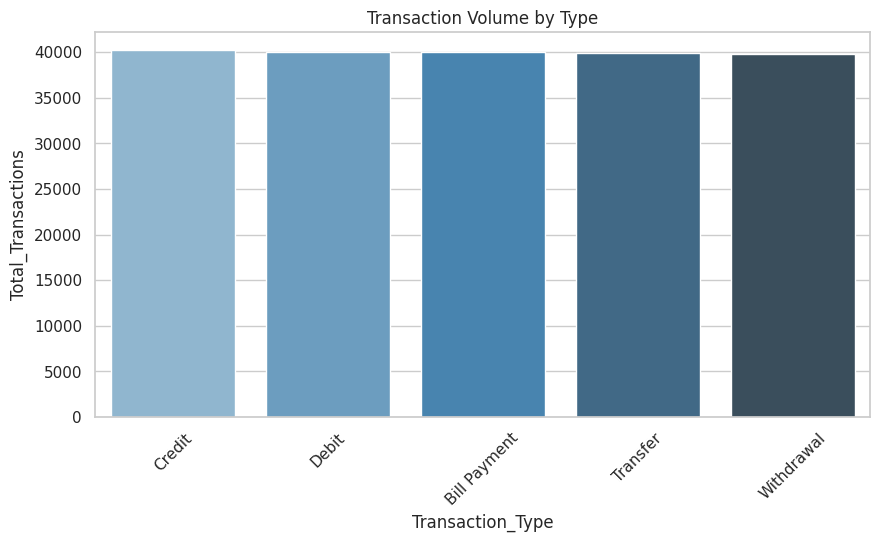

In [94]:
# 1. Visualize Transaction Patterns
pattern_pd = pattern_sql.toPandas()
plt.figure(figsize=(10, 5))
sns.barplot(data=pattern_pd, x='Transaction_Type', y='Total_Transactions', palette='Blues_d')
plt.title('Transaction Volume by Type')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_918/4279119266.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=branch_pd, x='Bank_Branch', y='Transaction_Volume', palette='viridis')


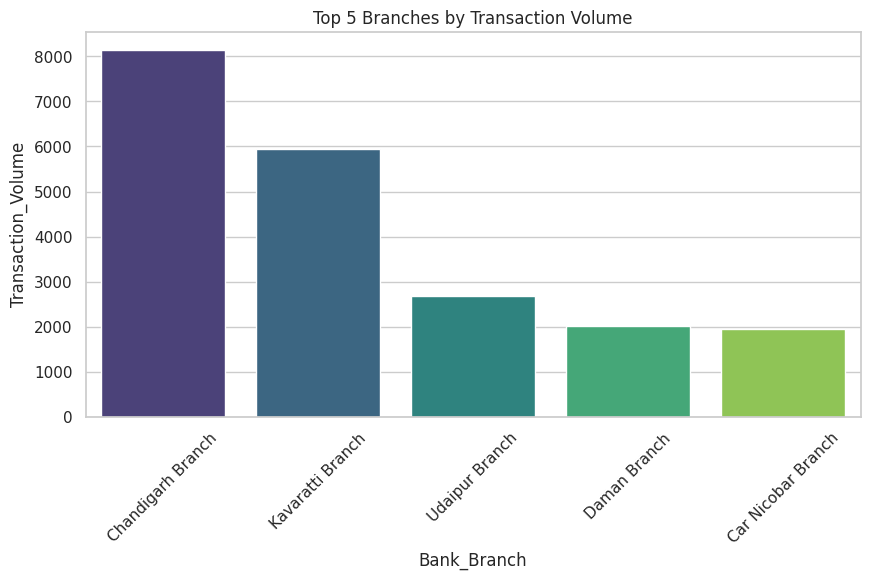

In [95]:
# 2. Visualize Top 5 Branches
branch_pd = branch_sql.toPandas()
plt.figure(figsize=(10, 5))
sns.barplot(data=branch_pd, x='Bank_Branch', y='Transaction_Volume', palette='viridis')
plt.title('Top 5 Branches by Transaction Volume')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_918/2994673370.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=suspicious_pd, x='Device_Type', y='Fraud_Percentage', palette='Reds_d')


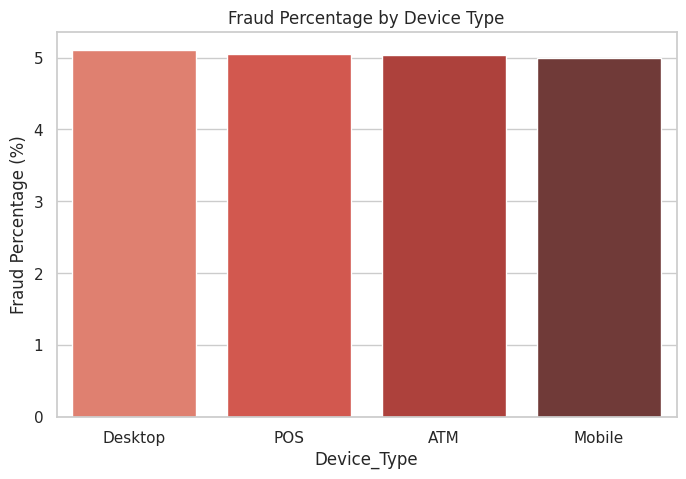

In [96]:
# 3. Visualize Suspicious Patterns (Fraud by Device)
suspicious_pd = suspicious_sql.toPandas()
plt.figure(figsize=(8, 5))
sns.barplot(data=suspicious_pd, x='Device_Type', y='Fraud_Percentage', palette='Reds_d')
plt.title('Fraud Percentage by Device Type')
plt.ylabel('Fraud Percentage (%)')
plt.show()

Let's analyze fraud percentage by age group. First, we need to calculate the fraud percentage per age group.

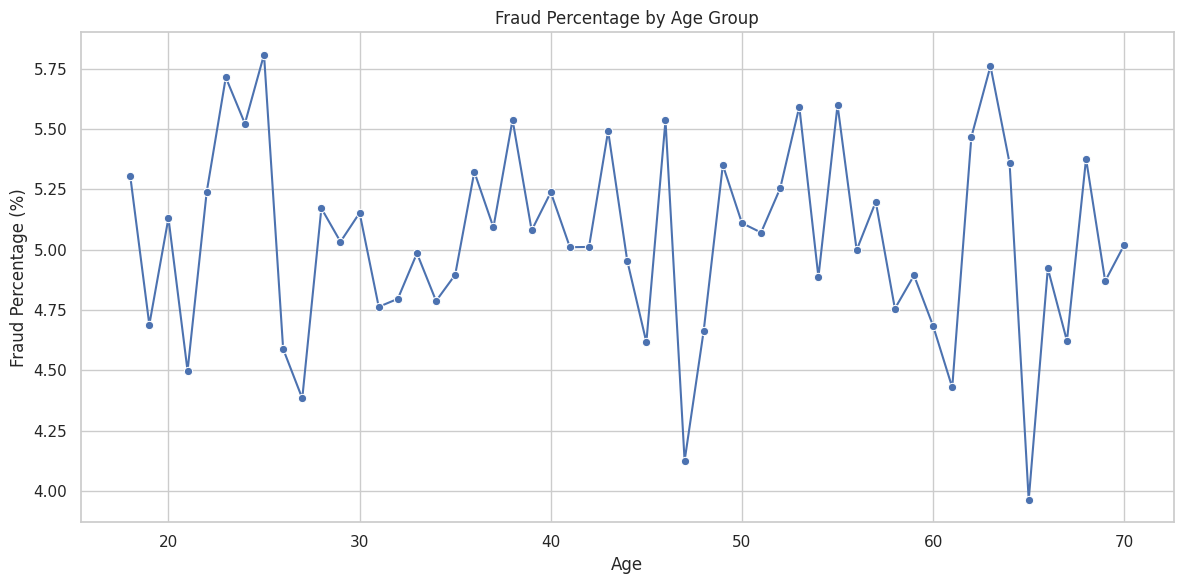

In [109]:
# Calculate fraud percentage by Age
fraud_by_age = df.groupBy('Age').agg(
    count('Is_Fraud').alias('Total_Transactions'),
    sum('Is_Fraud').alias('Fraud_Count')
).withColumn('Fraud_Percentage', (col('Fraud_Count') / col('Total_Transactions')) * 100)\
.orderBy('Age')

fraud_by_age_pd = fraud_by_age.toPandas()

plt.figure(figsize=(12, 6))
sns.lineplot(data=fraud_by_age_pd, x='Age', y='Fraud_Percentage', marker='o')
plt.title('Fraud Percentage by Age Group')
plt.xlabel('Age')
plt.ylabel('Fraud Percentage (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

Let's visualize the distribution of transaction amounts for fraudulent vs. non-fraudulent transactions.

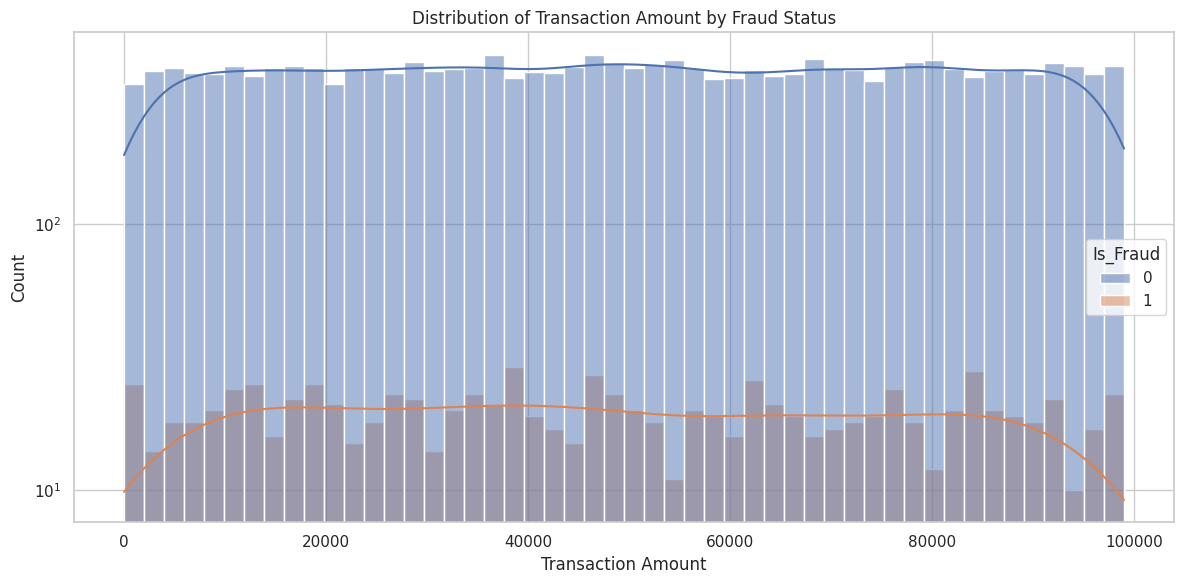

In [108]:
# Convert to Pandas for plotting
df_sample_pd = df.sample(False, 0.1, seed=42).toPandas() # Sample a subset for faster plotting

plt.figure(figsize=(12, 6))
sns.histplot(data=df_sample_pd, x='Transaction_Amount', hue='Is_Fraud', kde=True, bins=50)
plt.title('Distribution of Transaction Amount by Fraud Status')
plt.xlabel('Transaction Amount')
plt.ylabel('Count')
plt.yscale('log') # Use log scale for y-axis if there's a large difference in counts
plt.tight_layout()
plt.show()

## Q6 ETL Pipeline Development

In [110]:
from pyspark.sql.functions import col, to_date, current_timestamp

print("--- Starting ETL Pipeline ---")

# 1. EXTRACT (E)

print("1. Extracting data from multiple banking systems...")
# We use the 4 fragmented files created earlier to simulate multiple source systems
source_files = [
    "transactions_POS.csv",
    "transactions_Desktop.csv",
    "transactions_Mobile.csv",
    "transactions_ATM.csv"
]
raw_df = spark.read.csv(source_files, header=True, inferSchema=True)

--- Starting ETL Pipeline ---
1. Extracting data from multiple banking systems...


In [111]:
# 2. TRANSFORM & VALIDATE (T)

print("2. Transforming and validating data...")

# A. Validation: Remove any duplicate transactions based on Transaction_ID
transformed_df = raw_df.dropDuplicates(["Transaction_ID"])

# B. Validation: Drop rows where critical fields are missing (Nulls)
transformed_df = transformed_df.dropna(subset=["Customer_ID", "Transaction_Amount"])

# C. Transformation: Convert string dates (DD-MM-YYYY) into proper Spark DateType objects
transformed_df = transformed_df.withColumn("Transaction_Date", to_date(col("Transaction_Date"), "dd-MM-yyyy"))

# D. Transformation: Add a metadata column to track when the ETL job ran
transformed_df = transformed_df.withColumn("ETL_Processed_At", current_timestamp())

2. Transforming and validating data...


In [112]:
# 3. LOAD (L)

print("3. Loading data into the centralized data repository...")

# Define the output directory for the centralized repository
central_repo_path = "centralized_data_repository/transactions.parquet"

# Save as Parquet (The industry standard for Big Data storage)
# We use mode("overwrite") so you can re-run this cell without throwing an error
transformed_df.write.mode("overwrite").parquet(central_repo_path)

print(f"--- ETL Pipeline Completed! Data successfully loaded to: {central_repo_path} ---")

# Quick verification to prove the Load was successful
print("\nVerifying Centralized Data Repository:")
spark.read.parquet(central_repo_path).select("Transaction_ID", "Transaction_Date", "ETL_Processed_At").show(3, truncate=False)

3. Loading data into the centralized data repository...
--- ETL Pipeline Completed! Data successfully loaded to: centralized_data_repository/transactions.parquet ---

Verifying Centralized Data Repository:
+------------------------------------+----------------+--------------------------+
|Transaction_ID                      |Transaction_Date|ETL_Processed_At          |
+------------------------------------+----------------+--------------------------+
|000056a8-97a8-48bb-98f5-018eb1c4f938|2025-01-11      |2026-07-02 19:25:58.638467|
|0000740e-2725-4b9d-8855-d8ff2f209272|2025-01-13      |2026-07-02 19:25:58.638467|
|00009acc-ee5d-466e-9137-fae1557d9bb4|2025-01-25      |2026-07-02 19:25:58.638467|
+------------------------------------+----------------+--------------------------+
only showing top 3 rows


## Q7 Machine Learning/Deep Learning Implementation

In [114]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [147]:
# 1. Define your categorical columns
categorical_cols = [
    'Gender','City', 'Account_Type', 'Transaction_Type',
    'Merchant_Category', 'Device_Type'
]

In [148]:
# 2. Apply StringIndexer to all categorical columns
df_ml = df
for col_name in categorical_cols:
    indexer = StringIndexer(inputCol=col_name, outputCol=f"{col_name}_Index", handleInvalid="keep")
    df_ml = indexer.fit(df_ml).transform(df_ml)

In [149]:
df_ml.show(5)

+--------------------+---------------+------+---+------------+---------+----------------+------------+--------------------+----------------+-------------------+------------------+--------------------+----------------+-----------------+---------------+--------------------+--------------------+-----------+--------+--------------------+----------------+-----------------------+--------------------+------------+----------+------------------+----------------------+-----------------------+-----------------+
|         Customer_ID|  Customer_Name|Gender|Age|       State|     City|     Bank_Branch|Account_Type|      Transaction_ID|Transaction_Date|   Transaction_Time|Transaction_Amount|         Merchant_ID|Transaction_Type|Merchant_Category|Account_Balance|  Transaction_Device|Transaction_Location|Device_Type|Is_Fraud|Transaction_Currency|Customer_Contact|Transaction_Description|      Customer_Email|Gender_Index|City_Index|Account_Type_Index|Transaction_Type_Index|Merchant_Category_Index|Device_

In [150]:
# 3. Combine numeric columns with your newly indexed categorical columns
numeric_cols = ['Age', 'Transaction_Amount', 'Account_Balance']
indexed_cols = [f"{c}_Index" for c in categorical_cols]
assembler_inputs = numeric_cols + indexed_cols

In [151]:
assembler_inputs

['Age',
 'Transaction_Amount',
 'Account_Balance',
 'Gender_Index',
 'City_Index',
 'Account_Type_Index',
 'Transaction_Type_Index',
 'Merchant_Category_Index',
 'Device_Type_Index']

In [152]:
# 4. Assemble into a single 'features' vector
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")
data_ml = assembler.transform(df_ml)

In [155]:
data_ml.show(5, truncate=False)

+------------------------------------+---------------+------+---+------------+---------+----------------+------------+------------------------------------+----------------+-------------------+------------------+------------------------------------+----------------+-----------------+---------------+----------------------+-----------------------+-----------+--------+--------------------+----------------+-----------------------+-----------------------+------------+----------+------------------+----------------------+-----------------------+-----------------+--------------------------------------------------+
|Customer_ID                         |Customer_Name  |Gender|Age|State       |City     |Bank_Branch     |Account_Type|Transaction_ID                      |Transaction_Date|Transaction_Time   |Transaction_Amount|Merchant_ID                         |Transaction_Type|Merchant_Category|Account_Balance|Transaction_Device    |Transaction_Location   |Device_Type|Is_Fraud|Transaction_Currency

In [158]:
# 5. Train/Test Split & Model Training
train_data, test_data = data_ml.randomSplit([0.8, 0.2], seed=42)

rf = RandomForestClassifier(labelCol="Is_Fraud", featuresCol="features", numTrees=20, maxBins=256)
rf_model = rf.fit(train_data)

In [133]:
# 6. Evaluation
predictions = rf_model.transform(test_data)
evaluator = MulticlassClassificationEvaluator(labelCol="Is_Fraud", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 94.79%


In [159]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print("--- Starting Deep Neural Network (DNN) Implementation ---")

# 1. Define the Neural Network Architecture (The Layers)
# - Input layer: 8 neurons (Matches the 8 features we created: 3 numeric + 5 indexed categorical)
# - Hidden layers: 16 neurons, then 8 neurons (You can tune these)
# - Output layer: 2 neurons (Binary classification: 0 = Not Fraud, 1 = Fraud)
layers = [9, 32,16, 8, 2]

# 2. Initialize the Multilayer Perceptron Classifier
dnn = MultilayerPerceptronClassifier(
    maxIter=100,           # Number of training iterations (epochs)
    layers=layers,         # The architecture defined above
    blockSize=128,         # Number of records per batch
    seed=42,
    featuresCol="features",
    labelCol="Is_Fraud"
)

# 3. Train the Model
dnn_model = dnn.fit(train_data)



--- Starting Deep Neural Network (DNN) Implementation ---


In [161]:
# 4. Generate Predictions on the Test Dataset
dnn_predictions = dnn_model.transform(test_data)


In [162]:
# 5. Model Evaluation
evaluator = MulticlassClassificationEvaluator(
    labelCol="Is_Fraud", predictionCol="prediction", metricName="accuracy"
)
dnn_accuracy = evaluator.evaluate(dnn_predictions)

print(f"\n--- DNN Model Evaluation ---")
print(f"Deep Neural Network Accuracy: {dnn_accuracy * 100:.2f}%")


--- DNN Model Evaluation ---
Deep Neural Network Accuracy: 94.79%


In [163]:
# 6. Show a sample of actual vs predicted values
print("\nSample DNN Predictions:")
dnn_predictions.select("Transaction_Amount", "Is_Fraud", "prediction", "probability").show(5, truncate=False)


Sample DNN Predictions:
+------------------+--------+----------+-----------------------------------------+
|Transaction_Amount|Is_Fraud|prediction|probability                              |
+------------------+--------+----------+-----------------------------------------+
|12248.24          |0       |0.0       |[0.9487003907302441,0.05129960926975584] |
|14603.12          |0       |0.0       |[0.9498386226712482,0.050161377328751706]|
|23026.48          |1       |0.0       |[0.9499106271480453,0.05008937285195478] |
|66500.87          |0       |0.0       |[0.9502633608763575,0.04973663912364248] |
|29439.12          |0       |0.0       |[0.9498386226712482,0.050161377328751706]|
+------------------+--------+----------+-----------------------------------------+
only showing top 5 rows


In [127]:
df.select("Transaction_Currency").distinct().show(500, truncate=False)

+--------------------+
|Transaction_Currency|
+--------------------+
|INR                 |
+--------------------+



In [ ]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator












In [113]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print("--- Starting Machine Learning Implementation (Fraud Prediction) ---")

# 1. Feature Engineering (String Indexing)
# Machine Learning models require numerical input. We must convert categorical strings to numbers.
indexer_device = StringIndexer(inputCol="Device_Type", outputCol="Device_Index")
indexer_type = StringIndexer(inputCol="Transaction_Type", outputCol="Type_Index")

df_ml = indexer_device.fit(df).transform(df)
df_ml = indexer_type.fit(df_ml).transform(df_ml)

# 2. Vector Assembling
# Combine all chosen feature columns into a single vector column named "features"
# We are using Age, Amount, and our newly indexed categorical columns
assembler = VectorAssembler(
    inputCols=["Age", "Transaction_Amount", "Device_Index", "Type_Index"],
    outputCol="features"
)
data_ml = assembler.transform(df_ml)

# 3. Train/Test Split
# Split the dataset 80% for training and 20% for testing
train_data, test_data = data_ml.randomSplit([0.8, 0.2], seed=42)

# 4. Model Training
# Initialize and train a Random Forest Classifier
rf = RandomForestClassifier(labelCol="Is_Fraud", featuresCol="features", numTrees=20)
print("Training the Random Forest model... (This may take a moment)")
rf_model = rf.fit(train_data)

# 5. Model Evaluation
# Generate predictions on the test dataset
predictions = rf_model.transform(test_data)

# Evaluate the model using Accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol="Is_Fraud", predictionCol="prediction", metricName="accuracy"
)
accuracy = evaluator.evaluate(predictions)

print(f"\n--- Model Evaluation ---")
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")

# Show a sample of actual vs predicted values
print("\nSample Predictions:")
predictions.select("Transaction_Amount", "Is_Fraud", "prediction", "probability").show(5, truncate=False)

--- Starting Machine Learning Implementation (Fraud Prediction) ---
Training the Random Forest model... (This may take a moment)

--- Model Evaluation ---
Random Forest Accuracy: 94.79%

Sample Predictions:
+------------------+--------+----------+----------------------------------------+
|Transaction_Amount|Is_Fraud|prediction|probability                             |
+------------------+--------+----------+----------------------------------------+
|12248.24          |0       |0.0       |[0.9501966350954411,0.04980336490455895]|
|14603.12          |0       |0.0       |[0.9504906062755287,0.04950939372447125]|
|23026.48          |1       |0.0       |[0.9501966350954411,0.04980336490455895]|
|66500.87          |0       |0.0       |[0.9501966350954411,0.04980336490455895]|
|29439.12          |0       |0.0       |[0.9501966350954411,0.04980336490455895]|
+------------------+--------+----------+----------------------------------------+
only showing top 5 rows
